In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
import numpy as np
from sklearn.preprocessing import PowerTransformer

df = pd.read_csv(r"..\Uncleaned dataset\District_City_Statistics_Raw.csv")
print(df.info())
print(df.describe())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                180 non-null    int64  
 1   District_City       180 non-null    object 
 2   Fatal               174 non-null    float64
 3   Non_Fatal_Injury    180 non-null    int64  
 4   Damage_to_Property  180 non-null    int64  
 5   Grand_Total         178 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 8.6+ KB
None
              Year       Fatal  Non_Fatal_Injury  Damage_to_Property  \
count   180.000000  174.000000        180.000000          180.000000   
mean   2019.500000   42.833333       1859.872222         6379.511111   
std       2.880293   88.420114       3872.748313        14690.607326   
min    2015.000000    0.000000          1.000000            2.000000   
25%    2017.000000    7.000000        463.750000          675.500000   
50%  

In [2]:
def unique(dataset):
    print(dataset.nunique())
    print(dataset.unique())

unique(df['Year'])
unique(df['District_City'])

10
[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
18
['Caloocan' 'Las Piñas' 'Makati' 'Malabon' 'Mandaluyong' 'Manila'
 'Marikina' 'Muntinlupa' 'Navotas' 'Parañaque' 'Pasay' 'Pasig' 'Pateros'
 'Quezon' 'San Juan' 'Taguig' 'Valenzuela' 'Grand Total']


In [3]:
del df['Grand_Total']
df = df[df['District_City'] != 'Grand Total']
unique(df['Year'])
unique(df['District_City'])
df = df.fillna(0)
df['Fatal'] = df['Fatal'].astype(int)
df['year_cat'] = pd.to_datetime(df['Year'], format='%Y').dt.year
print(df.head())

10
[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
17
['Caloocan' 'Las Piñas' 'Makati' 'Malabon' 'Mandaluyong' 'Manila'
 'Marikina' 'Muntinlupa' 'Navotas' 'Parañaque' 'Pasay' 'Pasig' 'Pateros'
 'Quezon' 'San Juan' 'Taguig' 'Valenzuela']
   Year District_City  Fatal  Non_Fatal_Injury  Damage_to_Property  year_cat
0  2015      Caloocan     43              1130                2933      2015
1  2015     Las Piñas     24              1035                2357      2015
2  2015        Makati     19               969                9185      2015
3  2015       Malabon      5               418                 672      2015
4  2015   Mandaluyong      7               500                3715      2015


In [4]:
print(df.info())
df['Year'].value_counts()

<class 'pandas.core.frame.DataFrame'>
Index: 170 entries, 0 to 178
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Year                170 non-null    int64 
 1   District_City       170 non-null    object
 2   Fatal               170 non-null    int32 
 3   Non_Fatal_Injury    170 non-null    int64 
 4   Damage_to_Property  170 non-null    int64 
 5   year_cat            170 non-null    int32 
dtypes: int32(2), int64(3), object(1)
memory usage: 8.0+ KB
None


Year
2015    17
2016    17
2017    17
2018    17
2019    17
2020    17
2021    17
2022    17
2023    17
2024    17
Name: count, dtype: int64

array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Fatal'}>],
       [<Axes: title={'center': 'Non_Fatal_Injury'}>,
        <Axes: title={'center': 'Damage_to_Property'}>],
       [<Axes: title={'center': 'year_cat'}>, <Axes: >]], dtype=object)

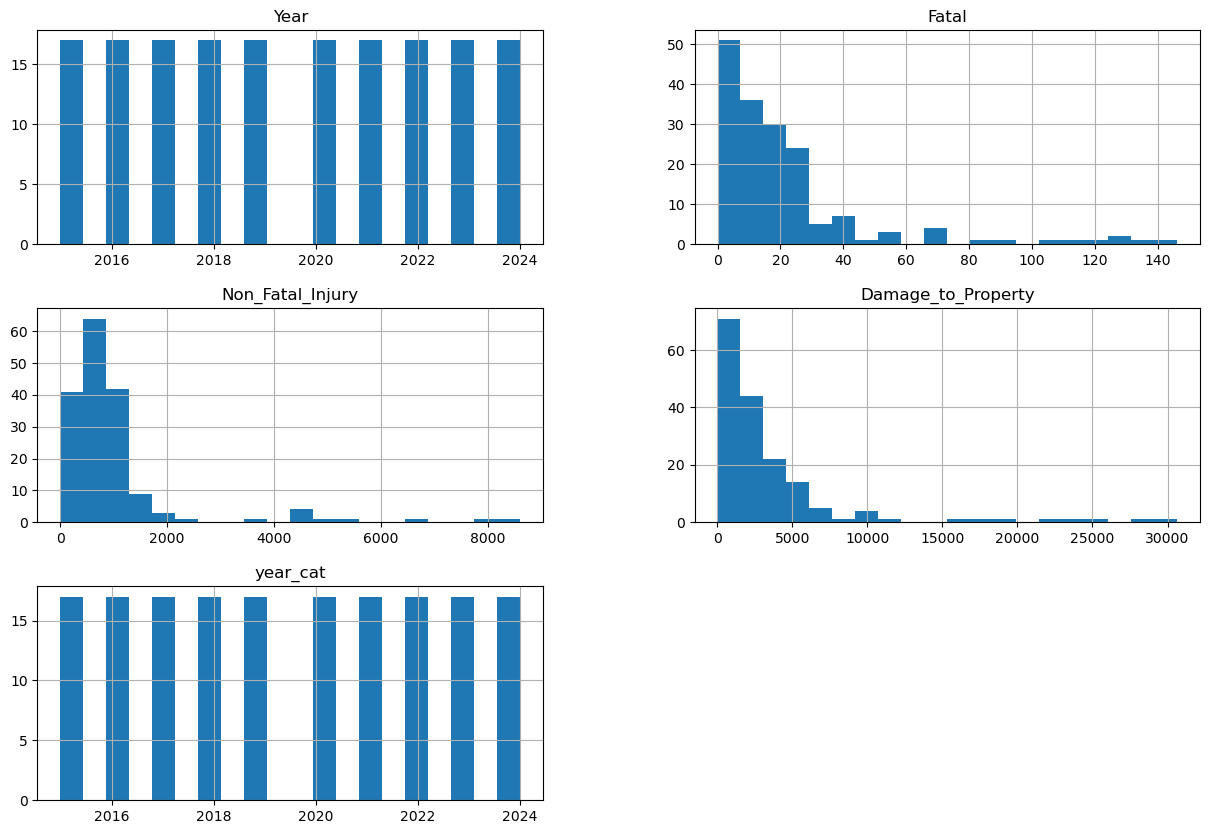

In [5]:
df.hist(figsize=(15, 10), bins=20)

In [6]:
pt = PowerTransformer(method='yeo-johnson')
def skew_check(dataset,val):
    print("Skewness Check:")
    for col in val:
        skew = dataset[col].skew()
        print(f"{col:10s}: {skew:6.2f} {'TRANSFORM' if abs(skew) > 1 else 'OK'}")
        
df_ML = df.copy()
skew_check(df,['Fatal','Damage_to_Property','Non_Fatal_Injury'])
df_ML['Fatal_log1p'] = np.log1p(df['Fatal'])
df_ML['Damage_to_Property_log'] = np.log(df['Damage_to_Property'])
df_ML['Non_Fatal_Injury_transYeo'] = pt.fit_transform(df[['Non_Fatal_Injury']])
skew_check(df_ML,['Fatal_log1p','Damage_to_Property_log','Non_Fatal_Injury_transYeo'])

Skewness Check:
Fatal     :   2.75 TRANSFORM
Damage_to_Property:   3.39 TRANSFORM
Non_Fatal_Injury:   3.73 TRANSFORM
Skewness Check:
Fatal_log1p:  -0.46 OK
Damage_to_Property_log:  -0.90 OK
Non_Fatal_Injury_transYeo:   0.14 OK


<Figure size 1800x1000 with 0 Axes>

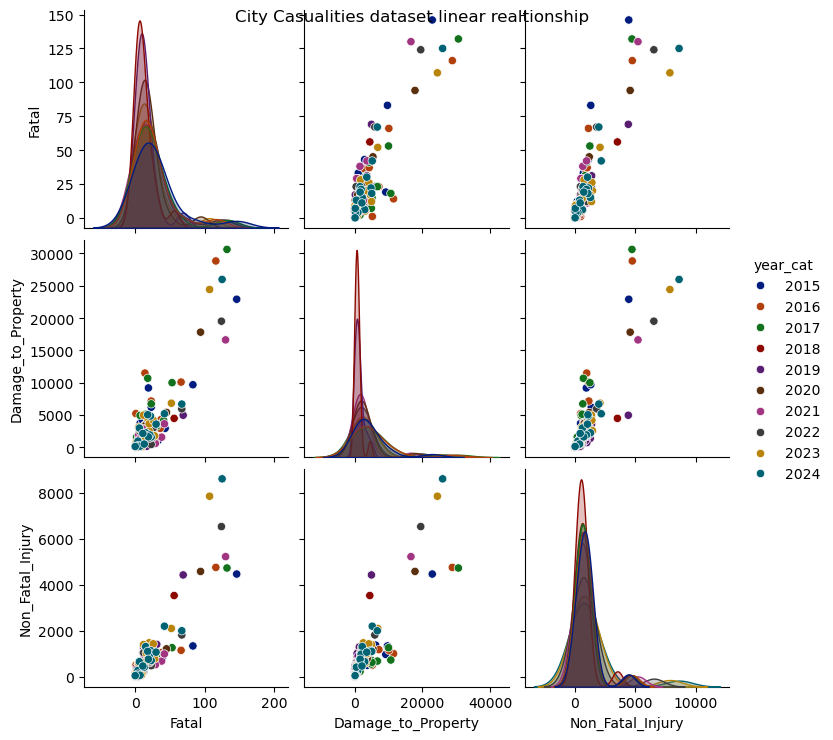

In [7]:
plt.figure(figsize=(18, 10))
sns.pairplot(df[['Fatal','Damage_to_Property','Non_Fatal_Injury'] + ['year_cat']], 
             diag_kind = 'kde', 
             hue = 'year_cat', 
             palette='dark')
plt.suptitle('City Casualities dataset linear realtionship')
plt.savefig('City Casualities dataset linear realtionship.png', dpi=300, bbox_inches='tight')
plt.show()

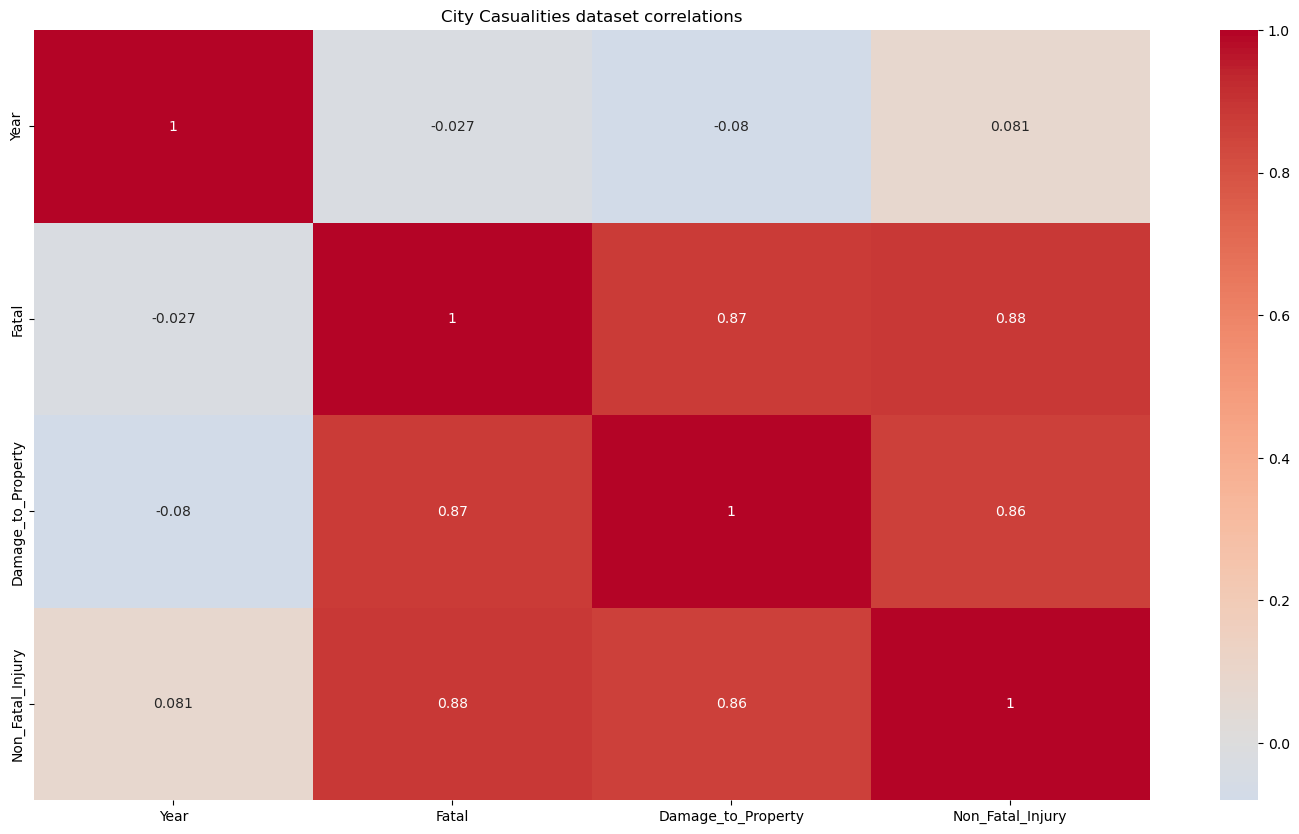

In [8]:
plt.figure(figsize=(18, 10))
sns.heatmap(df[['Year','Fatal','Damage_to_Property','Non_Fatal_Injury']].corr(),
            annot=True,
            cmap='coolwarm', 
            center=0)
plt.title('City Casualities dataset correlations')
plt.savefig('City Casualities dataset correlations.png', dpi=300, bbox_inches='tight')
plt.show()

array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Fatal'}>,
        <Axes: title={'center': 'Non_Fatal_Injury'}>],
       [<Axes: title={'center': 'Damage_to_Property'}>,
        <Axes: title={'center': 'year_cat'}>,
        <Axes: title={'center': 'Fatal_log1p'}>],
       [<Axes: title={'center': 'Damage_to_Property_log'}>,
        <Axes: title={'center': 'Non_Fatal_Injury_transYeo'}>, <Axes: >]],
      dtype=object)

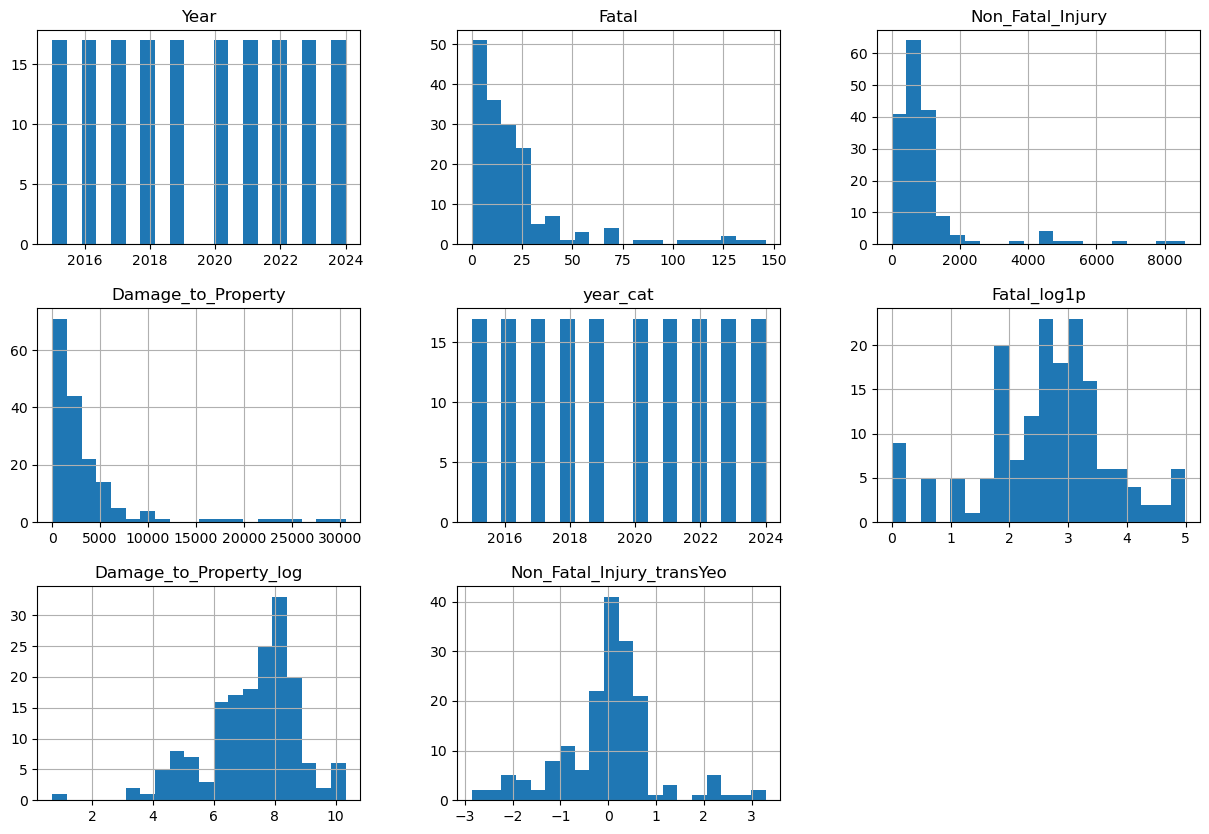

In [9]:
df_ML.hist(figsize=(15, 10), bins=20)

In [10]:
df.to_csv('District_City_Statistics.csv', index=False)
df_ML.to_csv('District_City_Statistics_ML.csv', index=False)